# Why Do We Need Attention Mechanism?

Before diving into Attention, it is important to understand **why Encoder–Decoder architecture alone is not enough**.

---

## Quick Recap: Encoder–Decoder Architecture
- Encoder processes the input sentence step by step (time step 1, 2, 3, …).  
- After the final step, it produces a **summary representation (context vector)**.  
- This fixed-length vector is passed to the Decoder.  
- Decoder then generates the output sequence step by step (e.g., word by word in translation).

---

## Problems with Encoder–Decoder

### 1. Burden on Encoder
- The encoder is forced to read an entire sentence, **compress all information into a single vector**, and pass it to the decoder.  
- For short sentences, this works.  
- For long sentences (>25 words), this becomes extremely difficult.  
- Just like humans cannot memorize and translate a 50-word sentence after reading it once, the encoder also struggles.

**Key Issue:**  
- We are asking the encoder to “remember everything at once,” which overloads the model.  

---

### 2. Decoder’s Limitation
- At each decoding step, do we really need the entire input sentence?  
  - Example: To generate the word **“light”**, we only need the source word **“lights”**, not the full sentence.  
  - To generate **“बंद”**, we only need the phrase **“turn off”**.  
- But in the Encoder–Decoder setup:  
  - The decoder only gets the **static context vector** (one fixed representation).  
  - This does not change across time steps.  
  - The decoder itself has to figure out which parts of the input are useful → inefficient and error-prone.

**Key Issue:**  
- Decoder has no way to **focus on specific parts** of the input during translation.  

---

## How Humans Translate
- When humans translate long sentences, we don’t memorize the whole sentence at once.  
- Instead, as we move through the text, we focus on **specific regions** at a time.  
- Our “attention span” dynamically shifts:  
  - Current region = clear focus.  
  - Rest of the sentence = blurry.  
- Translation happens **on the go**, not all at once.

---

## Solution: Attention Mechanism
- Attention introduces a way for the decoder to **dynamically choose relevant parts of the encoder’s output** at each time step.  
- Example:  
  - At Decoder time step 1 (printing **“light”**) → focus on Encoder’s time step 4.  
  - At Decoder time step 2 (printing **“बंद”**) → focus on Encoder’s time steps 1 and 2.  
- Attention computes a set of weights to decide **which encoder time steps are most important** for the current decoder output.

**In short:**  
- Instead of a single static summary vector, the decoder now gets **dynamic context vectors**.  
- These vectors highlight the most relevant input words for each output word.  

---

## Key Idea
Attention = A mechanism that tells the decoder:  
**“At this step, look at these specific parts of the input more carefully.”**


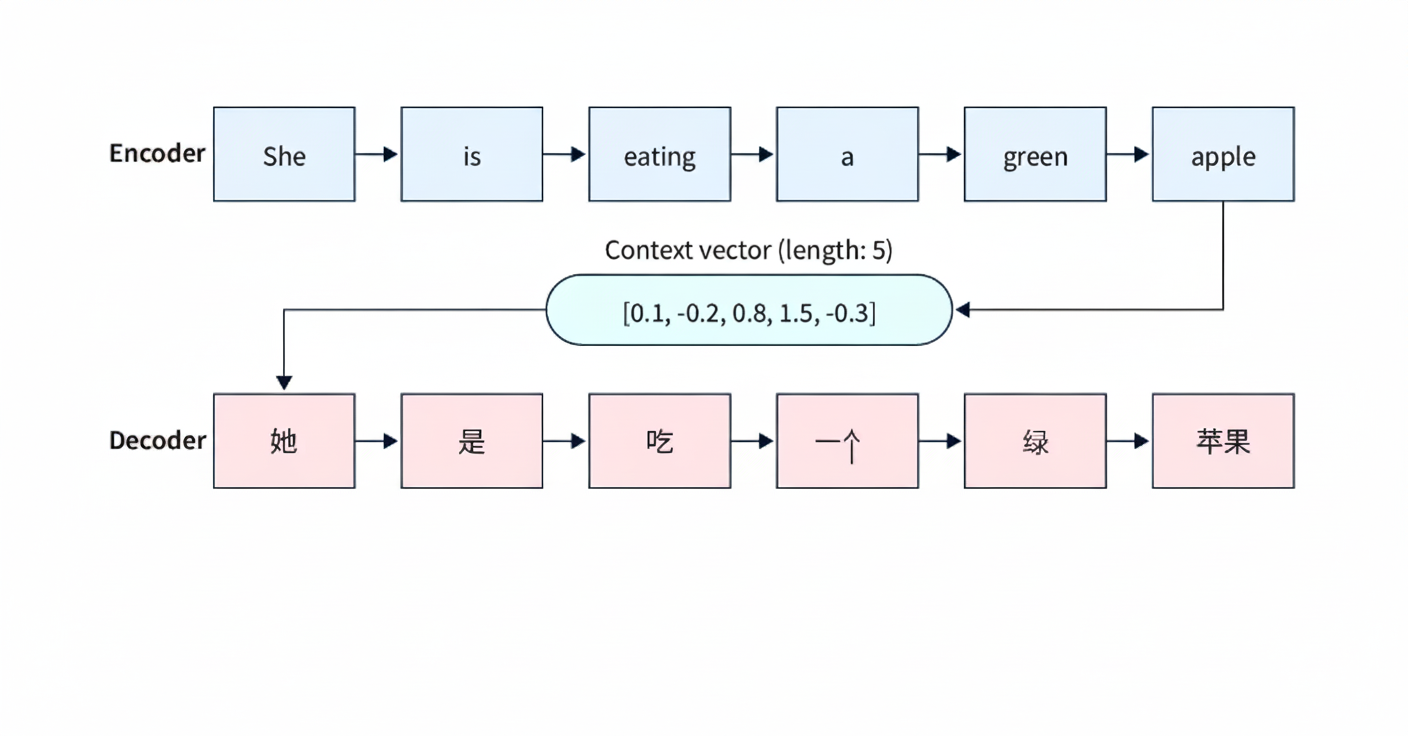

# Understanding Attention Mechanism (Step by Step)

---

## Encoder States
- The encoder processes the input sequence step by step.  
- At each time step `j`, the encoder produces a **hidden state** `h_j`.  
- Example: For 4 time steps → we get `h1, h2, h3, h4`.  
- Each `h_j` is a **vector** (from LSTM/GRU).

---

## Decoder States
- The decoder also maintains its own internal states, denoted as `s_i`.  
- Example: `s0, s1, s2, s3, s4` correspond to different decoding time steps.  
- Input to the decoder at each step also includes the true label (`y`) during training (teacher forcing).  
  - Example: `y0, y1, y2, y3`.

---

## Problem Setup
- In a vanilla Encoder–Decoder:
  - At time step `i`, the decoder takes:
    1. Previous state → `s_{i-1}`
    2. Current input (label) → `y_{i-1}`
- In Attention-based Encoder–Decoder:
  - At time step `i`, the decoder takes **three inputs**:
    1. Previous state → `s_{i-1}`
    2. Current input → `y_{i-1}`
    3. **Attention input (context vector)** → `c_i`

---

## What is `c_i` (Attention Input)?
- `c_i` tells the decoder which encoder hidden states are useful at time step `i`.  
- Example:
  - When generating **“light”**, `h4` is most useful.  
  - When generating **“बंद”**, both `h1` (“turn”) and `h2` (“off”) are useful.  
- Therefore:
  - `c_i` must be a **vector**, not a scalar or matrix.  
  - Its **dimension must match the encoder hidden state** (`h_j`).  
  - This ensures compatibility when combining with decoder states.

---

## Weighted Combination
- To compute `c_i`, we combine all encoder hidden states with weights.  
- Each encoder state `h_j` is assigned a weight `α_{ij}`.  
- These weights indicate the importance of `h_j` for decoder time step `i`.

**Equation:**
$$
c_i = \sum_{j} \alpha_{ij} \, h_j
$$

- Here:
  - `h_j` = encoder hidden state at time step `j`  
  - `α_{ij}` = attention weight (scalar)  
  - `c_i` = context vector for decoder step `i`

---

## How Many Weights?
- If encoder has `m` time steps and decoder has `n` time steps:  
  - Total weights needed = `n × m`  
- Example: If both have 4 steps each → `4 × 4 = 16` weights.

---

## Key Insight
- The **core challenge** is how to compute these attention weights (`α_{ij}`).  
- Once computed, they allow the decoder to **dynamically focus** on relevant encoder states for each output word.


# How Attention Weights (α) Are Calculated

---

## Alignment Score (α)
- Example: Consider **α₂₁**  
  - This is the alignment score (or similarity score) between:
    - Encoder’s **1st hidden state** (`h1`)  
    - Decoder’s **previous state** (`s1`)  
  - It tells us: *When generating the 2nd word in the output, how important is the 1st encoder hidden state?*

---

## General Form
- Any attention weight can be expressed as:
$$
\alpha_{ij} = f(h_j, s_{i-1})
$$
- Where:  
  - `h_j` = encoder hidden state at step `j`  
  - `s_{i-1}` = decoder’s previous hidden state  
  - `f()` = function that measures relevance (similarity)

---

## Choosing the Function `f()`
- Challenge: Which function should we use to calculate similarity?  
- Options could be dot product, cosine similarity, or other mathematical functions.  
- Instead of hand-crafting, researchers used the **power of neural networks**:
  - A small **feedforward neural network** is trained to learn the function.  
  - Since neural networks are **universal function approximators**, with enough data they can approximate the right similarity function.

---

## Neural Network for α
- Inputs to the small neural network:  
  1. Encoder hidden state `h_j`  
  2. Decoder previous state `s_{i-1}`  
- Output: **unnormalized score** (often called *energy* or *score*).  
- After applying **softmax** over all `j` for a fixed `i`, we get:
$$
\alpha_{ij} = \frac{\exp(\text{score}(s_{i-1}, h_j))}{\sum_k \exp(\text{score}(s_{i-1}, h_k))}
$$
- This ensures that attention weights for each decoder step sum to 1.

---

## Example for Decoder Step 2
- To compute `c2`:
  - Compute `α₂₁, α₂₂, α₂₃, α₂₄` using the neural network.  
  - Each weight tells how much `h1, h2, h3, h4` contribute.  
- Then:
$$
c_2 = \alpha_{21} h_1 + \alpha_{22} h_2 + \alpha_{23} h_3 + \alpha_{24} h_4
$$

---

## Benefits of Attention
- Overcomes the problem of long sentences degrading translation quality.  
- Empirical results show:
  - Vanilla encoder–decoder models degrade sharply beyond 30 words.  
  - Attention-based models maintain stable BLEU scores even with longer sentences.

---

## Visualization of Attention
- Since attention weights are explicitly available, they can be visualized.  
- For each output word, we can see which input words it attends to the most.  
- Example:  
  - “European” in French aligns strongly with “European” in English.  
  - “Agreement” aligns strongly with “Accord”.  
- Such **alignment matrices** give interpretability to the model.

---

## Bi-directional Encoder
- In the original attention paper, researchers used a **Bi-directional LSTM** for the encoder.  
- Advantage:
  - At any step, the encoder has access to both **past** and **future** context.  
  - Improves translation quality.  
- Decoder remained **uni-directional**, only encoder was bi-directional.  
- The overall attention mechanism (alignment model) remains the same.

---

## Summary
- Attention weight `α_{ij}` = similarity between `s_{i-1}` and `h_j`.  
- Learned via a **neural network** that is jointly trained with the model.  
- Context vector:
$$
c_i = \sum_j \alpha_{ij} h_j
$$
- Attention stabilizes translation for long sentences and provides interpretability through visualization.


### Bahdanau Attention

Before understanding Bahdanau Attention, we need to clarify the main objective:  
We want to compute the values of **α (alpha)**, also called **alignment scores**.  
- These scores determine how much weight a particular encoder hidden state contributes at a specific decoder timestep.  
- For example:  
  - α<sub>1,1</sub> tells us how much the word *Turn* contributes when generating the word *Light*.  
  - α<sub>2,1</sub> tells us how much the word *Turn* contributes when generating the word *Band (बंद)*.

---

#### Dependence of α (alignment score)
To calculate α<sub>i,j</sub>, it depends on two factors:
1. **Encoder hidden state (h<sub>j</sub>)** → because we are evaluating contribution of a specific input word.  
2. **Previous decoder hidden state (s<sub>i-1</sub>)** → because the contribution also depends on what has already been translated.

So, in general:
$$
\alpha_{i,j} = f(h_j, s_{i-1})
$$

This means:  
- Alignment scores are a function of both encoder hidden states and the previous decoder state.  
- The previous decoder state captures the translation history, providing context.

---

#### Choice of Function
The question is: what function *f* should we use?  
- In theory, many mathematical functions are possible (e.g., exponential, cosine similarity, etc.).  
- Bahdanau proposed instead of manually designing the function, we let a **feed-forward neural network** learn it.

---

#### Steps in Bahdanau Attention
1. Input **s<sub>i-1</sub>** (previous decoder state) and **h<sub>j</sub>** (encoder hidden state) into a small feed-forward neural network.  
2. The network outputs an **unnormalized score e<sub>i,j</sub>**.  
3. Apply **softmax** over all e<sub>i,j</sub> (for all j) to get the normalized alignment weights α<sub>i,j</sub>.  
4. Use α<sub>i,j</sub> to compute the context vector c<sub>i</sub> as the weighted sum of encoder hidden states.  
5. Feed c<sub>i</sub> into the decoder to generate the output y<sub>i</sub>.

---

#### Flow of Bahdanau Attention
- Encoder hidden states (h<sub>1</sub>, h<sub>2</sub>, …, h<sub>n</sub>) are computed.  
- At each decoder timestep *i*:  
  - Take s<sub>i-1</sub> and each h<sub>j</sub>, pass them through a feed-forward neural network → e<sub>i,j</sub>.  
  - Normalize using softmax → α<sub>i,j</sub>.  
  - Compute c<sub>i</sub> = Σ α<sub>i,j</sub> h<sub>j</sub>.  
  - Use c<sub>i</sub> and s<sub>i-1</sub> to produce the next output y<sub>i</sub>.  

This mechanism allows the decoder to dynamically focus on the most relevant parts of the input sequence at each step.


### Attention Mechanism – Architecture and Mathematical Formulation

In the architecture, the **encoder** remains the same as before, but the **decoder** is modified by adding a small feed-forward neural network. This neural network has:
- One hidden layer with 3 units.
- An output layer with 1 unit.
- Input layer size depends on the concatenated vectors.

---

#### Hidden States
- Encoder hidden states: $( h_1, h_2, h_3, h_4 $), each is a 4-dimensional vector.
- Decoder hidden states: $( s_0, s_1, s_2, \dots $), also 4-dimensional vectors.

---

#### Step 1: Context Vector Calculation
1. At time step $( t=1 $), the decoder needs a **context vector** $( c_1 $).
2. To compute $( c_1 $), we calculate **attention weights** ($(\alpha_{1j}$)) for each encoder hidden state.
3. The attention weights depend on:
   - The previous decoder hidden state $( s_{t-1} $).
   - The encoder hidden states $( h_j $).

---

#### Neural Network for Attention
- We concatenate $( s_{t-1} $) (4D) with each $( h_j $) (4D) → gives an 8D vector.
- For 4 encoder states, this forms a $( 4 \times 8 $) matrix.
- This matrix is passed through the feed-forward network:
  - First weight matrix $( W_d $) of shape $( 8 \times 3 $) → output $( 4 \times 3 $).
  - Apply non-linearity and bias.
  - Multiply with second weight matrix $( V $) of shape $( 3 \times 1 $) → output $( 4 \times 1 $).
  - The result is alignment scores $( e_{1j} $) for each encoder state.

---

#### Softmax Normalization
- Apply softmax on $( e_{1j} $) to obtain attention weights:
  $$
  \alpha_{1j} = \frac{\exp(e_{1j})}{\sum_{k=1}^{4} \exp(e_{1k})}
  $$
- These $(\alpha_{1j}$) values are positive and sum to 1.

---

#### Context Vector
- The context vector is the weighted sum of encoder states:
  $$
  c_1 = \sum_{j=1}^{4} \alpha_{1j} h_j
  $$

---

#### Decoder Update
- The decoder then takes:
  - Previous output $( y_{t-1} $),
  - Previous hidden state $( s_{t-1} $),
  - Context vector $( c_t $),
- And updates using the LSTM to produce:
  - New hidden state $( s_t $),
  - Predicted word $( y_t $).

---

#### Repetition Across Time Steps
- At $( t=2 $), repeat the same process with $( s_1 $), compute $( c_2 $), and generate $( y_2 $).
- This continues for all time steps.
- **Important:** The attention network parameters $( W_d, V $) remain the same across all time steps (time-distributed). They are updated only during **backpropagation**.

---

#### Mathematical Formulation
1. Context vector:
   $$
   c_i = \sum_{j=1}^{n} \alpha_{ij} h_j
   $$
2. Attention weights:
   $$
   \alpha_{ij} = \frac{\exp(e_{ij})}{\sum_{k=1}^{n} \exp(e_{ik})}
   $$
3. Alignment scores:
   $$
   e_{ij} = V^T \tanh(W_d [s_{i-1}; h_j] + b)
   $$

---

#### Terminology
- This mechanism is known as **Bahdanau Attention** or **Additive Attention**.
- The small feed-forward network is often referred to as the **alignment model**.
- Since the same attention parameters are reused at each decoder step, it is called a **time-distributed feed-forward neural network**.


# Luong Attention (Multiplicative Attention)

Luong Attention was introduced after Bahdanau Attention with some key improvements.  
The main purpose remains the same: for each decoder time step, compute which encoder hidden states are most relevant.  

## Key Differences from Bahdanau Attention
1. **Current Decoder Hidden State ($s_i$)**  
   - Bahdanau uses the *previous* decoder hidden state ($s_{i-1}$).  
   - Luong uses the *current* decoder hidden state ($s_i$).  
   - This provides more *updated information*, making translations more dynamic and accurate.

2. **Alignment Function**  
   - Bahdanau uses a small feed-forward neural network to compute alignment scores.  
   - Luong simplifies this by using the **dot product** between the decoder hidden state and encoder hidden states:  
     $$
     e_{ij} = s_i^\top h_j
     $$
   - Here, both $s_i$ (decoder state) and $h_j$ (encoder state) are vectors of the same dimension.  
   - The dot product gives a scalar similarity score.  
   - Higher similarity → higher alignment.  

   Then apply softmax over all encoder states to get attention weights:
   $$
   \alpha_{ij} = \frac{\exp(e_{ij})}{\sum_k \exp(e_{ik})}
   $$

3. **Context Vector Usage**  
   - In Bahdanau Attention, the context vector $c_i$ is fed into the **next input of the LSTM**.  
   - In Luong Attention, $c_i$ is instead **concatenated with the current decoder state** before generating the output.  
   - Final output vector:  
     $$
     \tilde{s}_i = \tanh(W_c [s_i ; c_i])
     $$
   - Then $\tilde{s}_i$ is passed through a feed-forward + softmax layer to produce the predicted word.

---

## Luong Attention Workflow
1. **Encoding Phase**  
   - Encoder processes input sequence → produces hidden states:  
     $h_1, h_2, h_3, ..., h_T$

2. **Decoding Phase**  
   - At time step $i$, decoder LSTM generates hidden state $s_i$.  
   - Compute alignment scores for each encoder state:  
     $e_{ij} = s_i^\top h_j$  
   - Apply softmax to get attention weights $\alpha_{ij}$.  
   - Compute context vector:  
     $c_i = \sum_j \alpha_{ij} h_j$

3. **Output Generation**  
   - Concatenate context vector with current decoder state:  
     $\tilde{s}_i = \tanh(W_c [s_i ; c_i])$  
   - Pass $\tilde{s}_i$ through output layer + softmax → predict word $y_i$.  

---

## Advantages of Luong Attention
- **Simpler**: avoids additional feed-forward neural network.  
- **Faster Training**: fewer parameters → efficient for long sentences.  
- **Better Performance**: using current decoder hidden state gives more updated context.  
- **Multiplicative Attention**: so called because alignment scores are computed via dot product.  

---

## Comparison: Bahdanau vs. Luong

| Aspect                  | Bahdanau Attention (Additive)              | Luong Attention (Multiplicative)      |
|--------------------------|--------------------------------------------|---------------------------------------|
| Alignment function       | Feedforward neural network (additive)      | Dot product (multiplicative)          |
| Decoder state used       | Previous hidden state ($s_{i-1}$)          | Current hidden state ($s_i$)          |
| Context vector usage     | Input to decoder                           | Combined with output                  |
| Parameters               | More (extra network)                       | Fewer (simpler, faster)               |
| Performance              | Strong baseline, handles long dependencies | Faster, often better in practice      |

---

## Why These Attention Mechanisms Matter
- Bahdanau and Luong attention mechanisms laid the foundation for **self-attention** in Transformers.  
- A clear understanding of how alignment scores, attention weights, and context vectors are computed is essential before studying **Transformer-based models** like BERT and GPT.


```mermaid
flowchart TD
    A[Input Sequence] --> B[Encoder]
    B -->|h1,h2,...,hn| C[Hidden States]

    C --> D[Dot Product with Current Decoder State si]
    D --> E[Alignment Scores eij]
    E --> F[Softmax → Attention Weights αij]
    F --> G[Context Vector ci]

    G --> H[Concatenate with Decoder Output si]
    H --> I[Feedforward + Softmax]
    I --> J[Final Output Word]



And here’s **Bahdanau Attention**:  


```mermaid
flowchart TD
    A[Input Sequence] --> B[Encoder]
    B -->|h1,h2,...,hn| C[Hidden States]

    C --> D[Feedforward NN with si-1 and hj]
    D --> E[Alignment Scores eij]
    E --> F[Softmax → Attention Weights αij]
    F --> G[Context Vector ci]

    G --> H[Input to Decoder along with si-1]
    H --> I[LSTM → si]
    I --> J[Final Output Word]
